<a href="https://colab.research.google.com/github/mglagan/mglagan.github.io/blob/main/OpenStreetMap_BuildingDensities.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building Densities

This script demonstrates the basic functionalities of GeoPandas by working with OpenStreetMap data. It extracts key features such as administrative boundaries, buildings, and roads, creates visualizations using Matplotlib, and calculates the building density for a selected region.


## Initialization

This section sets up the environment by installing and importing the necessary libraries.


In [ ]:
!pip install osmnx
!pip install pyrosm

In [ ]:
import osmnx as ox #for OSM data
import matplotlib.pyplot as plt #for visualization
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import geopandas as gpd #for GeoDataFrame (DataFrame with geometry column)
plt.style.use("dark_background") #for dark background

## Extracting OpenStreetMap Data

This script uses the `osmnx` library to analyze and visualize OpenStreetMap data for any city or municipality in the Philippines. It begins by downloading and initializing an OpenStreetMap data reader for the selected region, then extracts datasets for buildings, roads, and the administrative boundary. The script filters the buildings and roads to include only those intersecting with the specified administrative boundary, reprojects the selected data to the appropriate UTM Zone, and visualizes the reprojected buildings, roads, and boundary on a map.

In [ ]:
#Extracting administrative boundary data from OSM
takaoka_admin = ox.geocode_to_gdf('Takaoka County')
takaoka = ox.project_gdf(takaoka_admin)

In [ ]:
#Extracting building data from OSM
takaoka_bldg = ox.features.features_from_place(query='Takaoka County', tags={'building': True})
takaoka_bldg_proj = ox.project_gdf(takaoka_bldg)
takaoka_bldg_reset = takaoka_bldg_proj.reset_index("element_type")
takaoka_buildings = takaoka_bldg_reset.loc[takaoka_bldg_reset.geometry.geometry.type=='Polygon']

In [ ]:
#Extracting road data from OSM
takaoka_rd = ox.graph_from_place('Takaoka County', network_type='drive')
takaoka_rd_unproj = ox.graph_to_gdfs(takaoka_rd, nodes=False)
takaoka_roads = takaoka_rd_unproj.to_crs(epsg=32653)

<frozen importlib._bootstrap>:914: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _AltairImportHook.find_spec() not found; falling back to find_module()


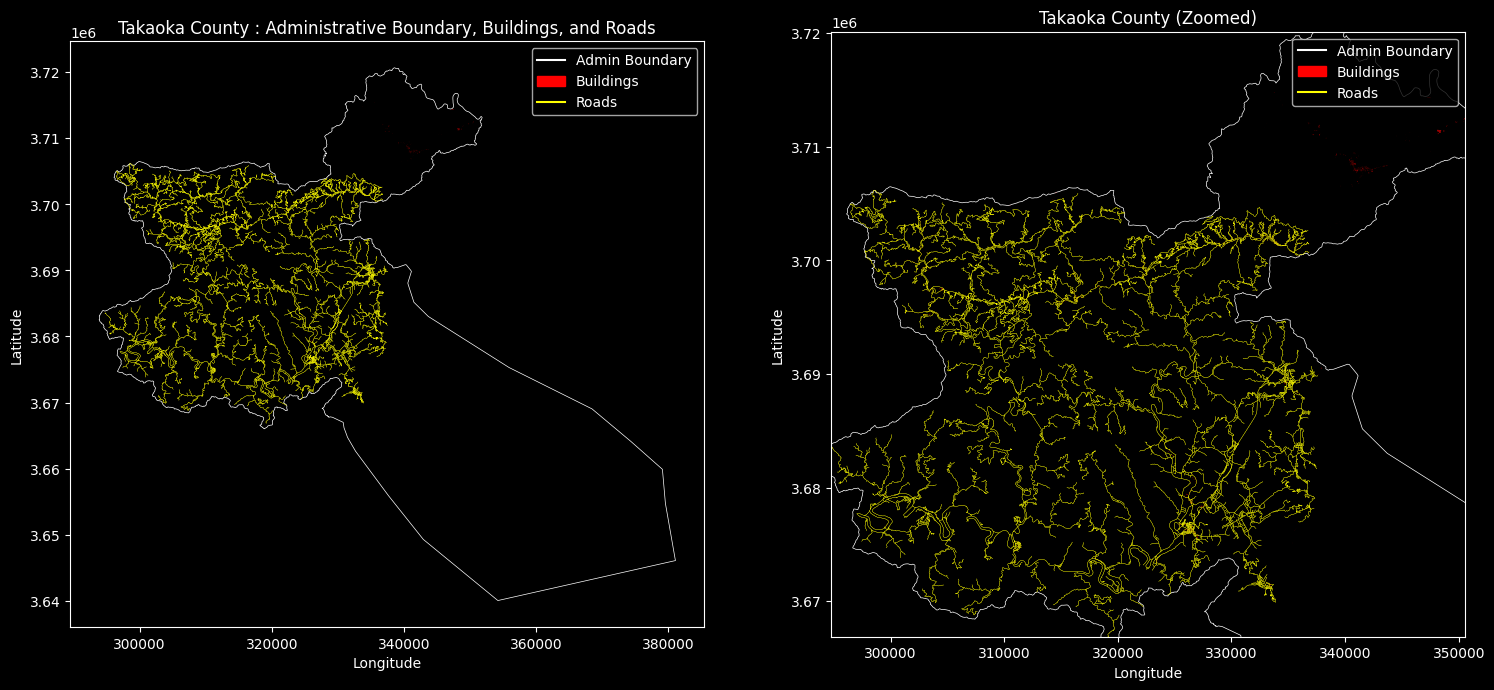

In [ ]:
fig, (full, zoom) = plt.subplots(1, 2, figsize=(18, 15))

#Plotting Takaoka County with buildings and roads
takaoka.plot(ax=full, color='none', edgecolor='white', linewidth=0.5, label='Administartive Boundary')
takaoka_buildings.plot(ax=full, color='red', alpha=1, label='Buildings')
takaoka_roads.plot(ax=full, color='yellow', linewidth=0.2, label='Roads')
full.set_title('Takaoka County : Administrative Boundary, Buildings, and Roads')

#Plotting Takaoka County in zoom
minx_b, miny_b, maxx_b, maxy_b = takaoka_buildings.total_bounds
minx_r, miny_r, maxx_r, maxy_r = takaoka_roads.total_bounds
minx, miny, maxx, maxy = min(minx_b, minx_r), min(miny_b, miny_r), max(maxx_b, maxx_r), max(maxy_b, maxy_r)
zoom.set_xlim(minx, maxx)
zoom.set_ylim(miny, maxy)
zoom.set_title('Takaoka County (Zoomed)')
takaoka.plot(ax=zoom, color='none', edgecolor='white', linewidth=0.5, label='Administartive Boundary')
takaoka_buildings.plot(ax=zoom, color='red', alpha=1, label='Buildings')
takaoka_roads.plot(ax=zoom, color='yellow', linewidth=0.2, label='Roads')

#Setting map legends
bound_leg = mlines.Line2D([], [], color='white', label='Admin Boundary')
building_leg = mpatches.Patch(color='red', label='Buildings')
road_leg = mlines.Line2D([], [], color='yellow', label='Roads')
full.set_xlabel('Longitude')
full.set_ylabel('Latitude')
zoom.set_xlabel('Longitude')
zoom.set_ylabel('Latitude')
full.legend(handles=[bound_leg, building_leg, road_leg], loc='upper right')
zoom.legend(handles=[bound_leg, building_leg, road_leg], loc='upper right')

plt.show()

## Overall Building Density


This script calculates building density by determining the total area of buildings within a city's boundary, dividing it by the city's total area, and printing the result as a percentage.


In [ ]:
#Calculating total area of all buildings within Takaoka County
takaoka_buildings["building_area"] = takaoka_buildings.area
total_building_area = takaoka_buildings['building_area'].sum()

#Calculating total area of Takaoka County
takaoka_area = takaoka.area.loc[0]

#Calculating the building density of Takaoka County
building_density = (total_building_area / takaoka_area) * 100

print(f"Building density in Takaoka County is {building_density:.1f} %.")

Building density in Takaoka County is 0.1 %.


## Building Density for Each Town

This script calculates building densities for all subregions e.g., towns, in a chosen city or municipality. Town boundaries are extracted from OpenStreetMap using the admin_level tag. For each town, the total building area is divided by the town's total area to compute the building density, expressed as a percentage.



In [ ]:
from pyrosm import OSM
from pyrosm import get_data

<frozen importlib._bootstrap>:914: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _AltairImportHook.find_spec() not found; falling back to find_module()


In [ ]:
#Getting data with admin_level from the region containing Takaoka County
shikoku_region = get_data("shikoku")
shikoku = OSM(shikoku_region)

In [ ]:
#Reading all boundaries with extra attributes
admin_boundaries = shikoku.get_boundaries(extra_attributes=["admin_level"])

<frozen importlib._bootstrap>:914: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _AltairImportHook.find_spec() not found; falling back to find_module()


In [ ]:
#Reading the boundary of Takaoka County
takaoka_county_unproj = admin_boundaries[admin_boundaries['name'] == "高岡郡"]
takaoka_county = takaoka_county_unproj.to_crs(epsg=32653)

#Extracting geometry of Takaoka Country
takaoka_geometry = takaoka_county.geometry.iloc[0]

In [ ]:
#Extracting the municipalies or towns from the region
towns_unproj = admin_boundaries[admin_boundaries['admin_level'] == "7"]
towns = towns_unproj.to_crs(epsg=32653)

#Determining the towns within Takaoka County
takaoka_towns_ini = towns[towns.within(takaoka_geometry)]
takaoka_towns = takaoka_towns_ini.dissolve(by='name')

In [ ]:
#Calculating the area of each town
takaoka_towns['town_area'] = takaoka_towns.geometry.area

#Initializing density of each town
takaoka_towns['density_%'] = 0

In [ ]:
#Iterating over towns; calculating building density of each town
for i, row in takaoka_towns.iterrows():
    town_geom = row['geometry']
    town_bldg = takaoka_buildings[takaoka_buildings.intersects(town_geom)] #finding buildings that intersects with takaoka area
    if not town_bldg.empty:
      town_bldg_area = town_bldg['building_area'].sum() #calculating total area of buildings in the town; building_area value from takaoka_buildings
      town_area = row['town_area']
      town_density = (town_bldg_area / town_area) * 100 #calculating town building density
      takaoka_towns.at[i, 'density_%'] = round(town_density, 1)

takaoka_towns.head(7)

<ipython-input-15-7794b455264c>:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.2' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  takaoka_towns.at[i, 'density_%'] = round(town_density, 1)
<frozen importlib._bootstrap>:914: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _BokehImpo

,geometry,ref,visible,admin_level,boundary,id,timestamp,version,tags,osm_type,addr:country,website,postal_code,start_date,changeset,town_area,density_%
name,,,,,,,,,,,,,,,,,
中土佐町,"POLYGON ((318649.395 3692495.397, 318649.466 3...",394017,None,7,administrative,1932767109,1720321079,10,"{""name:en"":""Nakatosa"",""name:ja"":""\u4E2D\u571F\...",relation,None,None,None,None,0.0,2.874611e+08,0.0
佐川町,"POLYGON ((332450.810 3705322.306, 332451.897 3...",394025,None,7,administrative,1888389115,1720321079,5,"{""name:en"":""Sakawa"",""name:ja"":""\u4F50\u5DDD\u7...",relation,None,None,None,None,0.0,1.011731e+08,0.2
四万十町,"POLYGON ((293854.202 3682543.942, 293880.221 3...",394122,None,7,administrative,1900490446,1720321079,15,"{""is_in:country"":""Japan"",""is_in:country_code"":...",relation,JP,None,None,None,0.0,1.903574e+09,0.0
日高村,"POLYGON ((342387.837 3713976.060, 342399.233 3...",394106,None,7,administrative,1969094871,1720321079,6,"{""name:en"":""Hidaka"",""name:ja"":""\u65E5\u9AD8\u6...",relation,None,None,None,None,0.0,4.484074e+07,0.2
檮原町,"POLYGON ((300304.549 3696385.695, 300303.330 3...",394050,None,7,administrative,1985241218,1720321079,7,"{""name:en"":""Yusuhara"",""name:ja"":""\u6AAE\u539F\...",relation,None,None,None,None,0.0,2.364786e+08,0.1
津野町,"POLYGON ((313160.216 3705630.439, 313173.660 3...",394114,None,7,administrative,1936803410,1720321079,7,"{""name:en"":""Tsuno"",""name:ja"":""\u6D25\u91CE\u75...",relation,None,None,None,None,0.0,1.980806e+08,0.3
越知町,"POLYGON ((328962.333 3704574.874, 328967.781 3...",394033,None,7,administrative,1864208720,1720321079,6,"{""name:en"":""Ochi"",""name:ja"":""\u8D8A\u77E5\u753...",relation,None,None,None,None,0.0,1.115432e+08,0.0


In [ ]:
#Translating town names to english
translation_dict = {
    '中土佐町': 'Nakatosa',
    '佐川町': 'Sakawa',
    '四万十町': 'Shimanto',
    '日高村': 'Hidaka',
    '檮原町': 'Yusuhara',
    '津野町': 'Tsuno',
    '越知町': 'Ochi'
}
takaoka_towns = takaoka_towns.reset_index() #reseting index to make name as a column

takaoka_towns['english_name'] = takaoka_towns['name'].replace(translation_dict)

takaoka_towns.head(7)

,name,geometry,ref,visible,admin_level,boundary,id,timestamp,version,tags,osm_type,addr:country,website,postal_code,start_date,changeset,town_area,density_%,english_name
0,中土佐町,"POLYGON ((318649.395 3692495.397, 318649.466 3...",394017,None,7,administrative,1932767109,1720321079,10,"{""name:en"":""Nakatosa"",""name:ja"":""\u4E2D\u571F\...",relation,None,None,None,None,0.0,2.874611e+08,0.0,Nakatosa
1,佐川町,"POLYGON ((332450.810 3705322.306, 332451.897 3...",394025,None,7,administrative,1888389115,1720321079,5,"{""name:en"":""Sakawa"",""name:ja"":""\u4F50\u5DDD\u7...",relation,None,None,None,None,0.0,1.011731e+08,0.2,Sakawa
2,四万十町,"POLYGON ((293854.202 3682543.942, 293880.221 3...",394122,None,7,administrative,1900490446,1720321079,15,"{""is_in:country"":""Japan"",""is_in:country_code"":...",relation,JP,None,None,None,0.0,1.903574e+09,0.0,Shimanto
3,日高村,"POLYGON ((342387.837 3713976.060, 342399.233 3...",394106,None,7,administrative,1969094871,1720321079,6,"{""name:en"":""Hidaka"",""name:ja"":""\u65E5\u9AD8\u6...",relation,None,None,None,None,0.0,4.484074e+07,0.2,Hidaka
4,檮原町,"POLYGON ((300304.549 3696385.695, 300303.330 3...",394050,None,7,administrative,1985241218,1720321079,7,"{""name:en"":""Yusuhara"",""name:ja"":""\u6AAE\u539F\...",relation,None,None,None,None,0.0,2.364786e+08,0.1,Yusuhara
5,津野町,"POLYGON ((313160.216 3705630.439, 313173.660 3...",394114,None,7,administrative,1936803410,1720321079,7,"{""name:en"":""Tsuno"",""name:ja"":""\u6D25\u91CE\u75...",relation,None,None,None,None,0.0,1.980806e+08,0.3,Tsuno
6,越知町,"POLYGON ((328962.333 3704574.874, 328967.781 3...",394033,None,7,administrative,1864208720,1720321079,6,"{""name:en"":""Ochi"",""name:ja"":""\u8D8A\u77E5\u753...",relation,None,None,None,None,0.0,1.115432e+08,0.0,Ochi


<ipython-input-17-308f5f0eb4fe>:11: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='right')


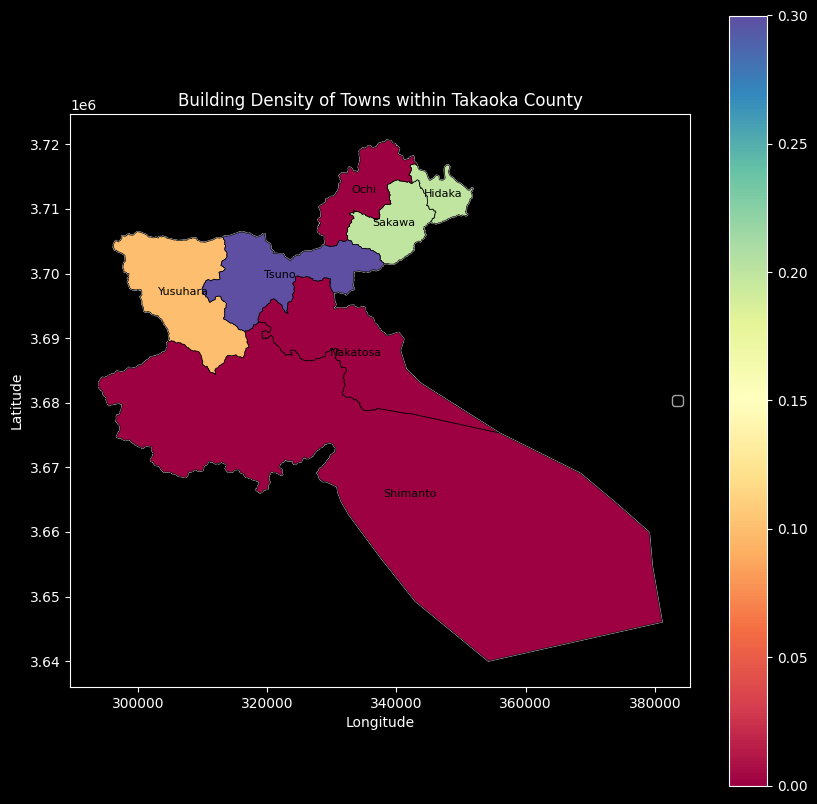

In [ ]:
#Visualizing the building density results
fig, dense = plt.subplots(figsize=(10, 10))

takaoka_county.plot(ax=dense, color='none', edgecolor='white', linewidth=1, label='Takaoka County')
takaoka_towns.plot(ax=dense, column='density_%', legend=True, cmap='Spectral', linewidth=0.5, edgecolor='black')

#Adding axis labels, legend, and title
dense.set_title('Building Density of Towns within Takaoka County')
dense.set_xlabel('Longitude')
dense.set_ylabel('Latitude')
plt.legend(loc='right')

#Adding town names to the plot
for x, y, label in zip(takaoka_towns.geometry.centroid.x, takaoka_towns.geometry.centroid.y, takaoka_towns.english_name):
    plt.text(x, y, label, fontsize=8, color="black", ha='center', va='center')

plt.show()
